In [21]:
import importlib
import cosinorage as csa

import utils
importlib.reload(utils)
from utils import recompute_wear_periods, plot_pig_wear_timeseries, save_modified_timeseries, compare_cohorts_daily_signal, load_cohort_data, plot_cohort_feature_comparison

### Computation of wear periods

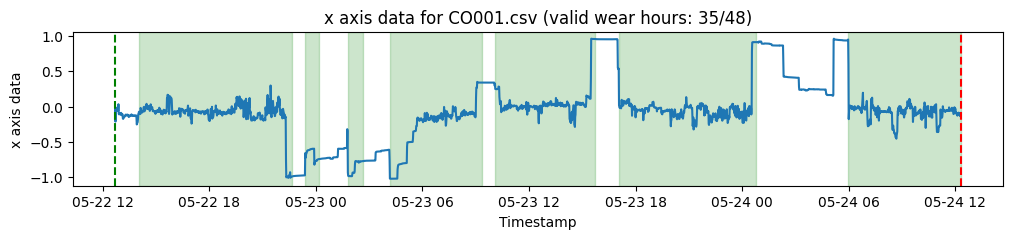

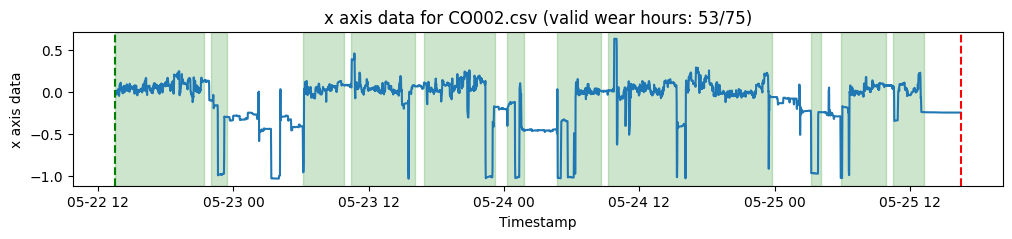

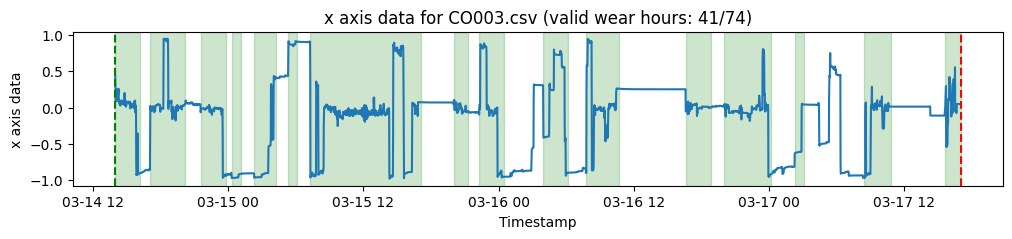

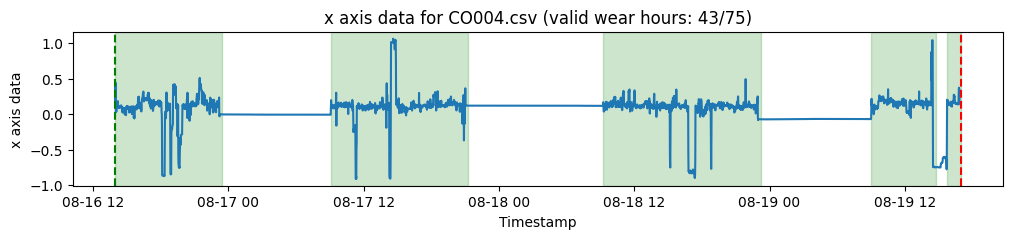

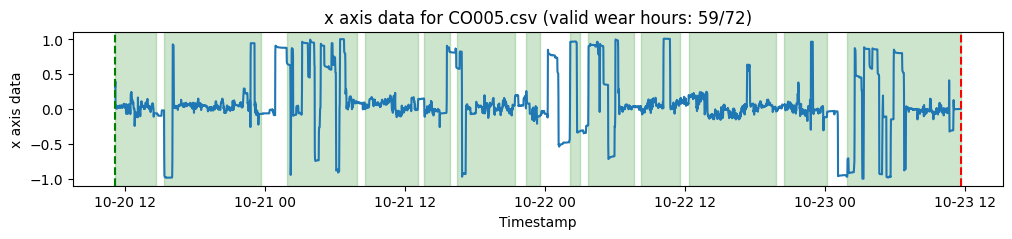

In [22]:
recompute_wear_periods()
plot_pig_wear_timeseries("wear_periods_recomputed.csv", "minute_level", limit=5, axis='x')

### Modification of values during during non-wear periods

During day time the mean of the timeseries is taken and during night time the values are set to 0.


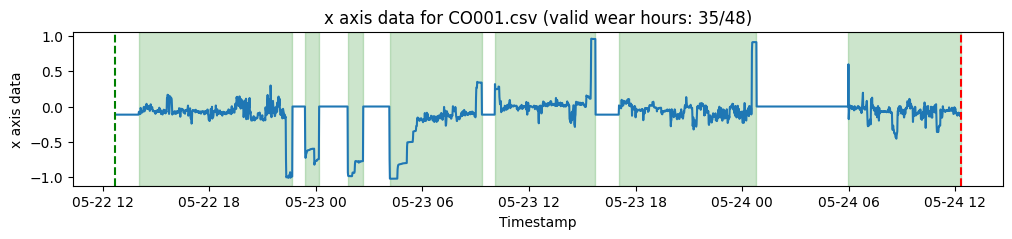

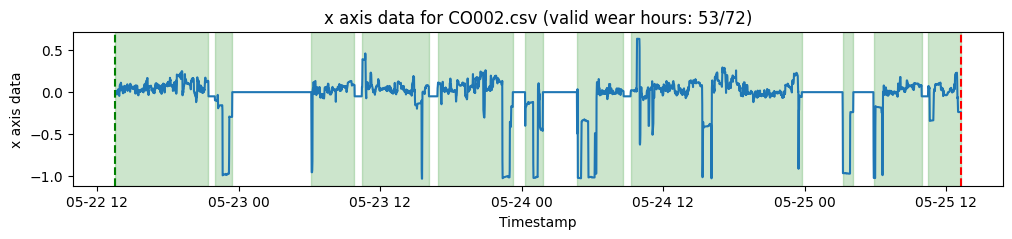

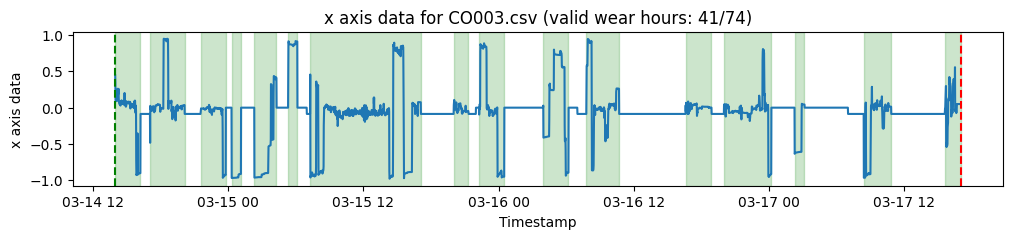

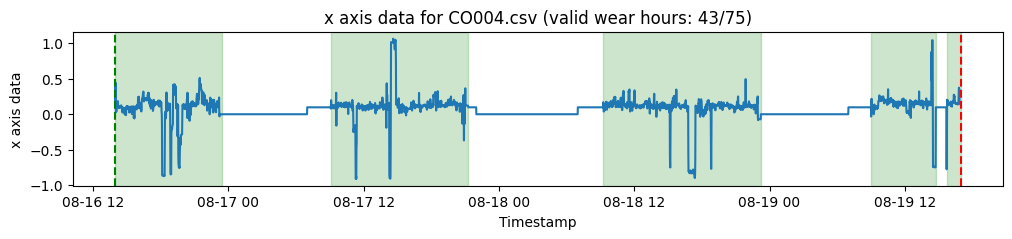

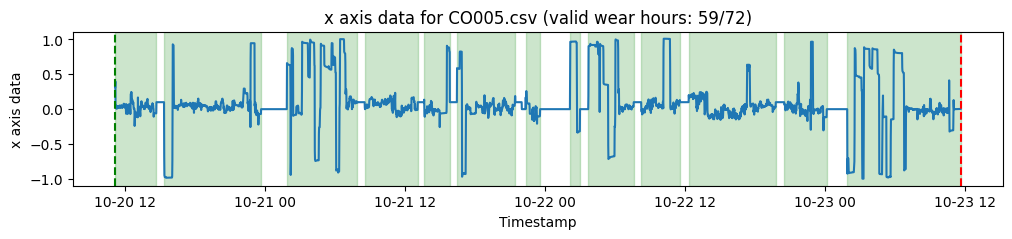

In [23]:
save_modified_timeseries("wear_periods_recomputed.csv", "minute_level", output_dir="minute_level_modified", max_wear_periods=1000, day_start="07:00", day_end="22:00")
plot_pig_wear_timeseries("wear_periods_recomputed.csv", "minute_level_modified", limit=5, axis='x')

### Average circadian rhythm per cohort 

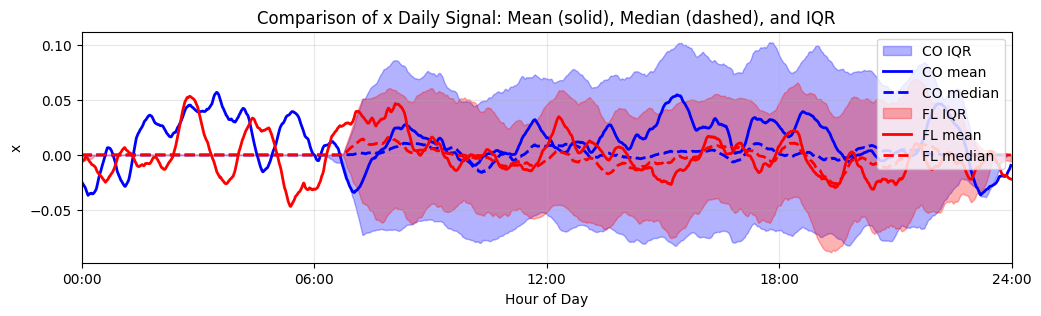

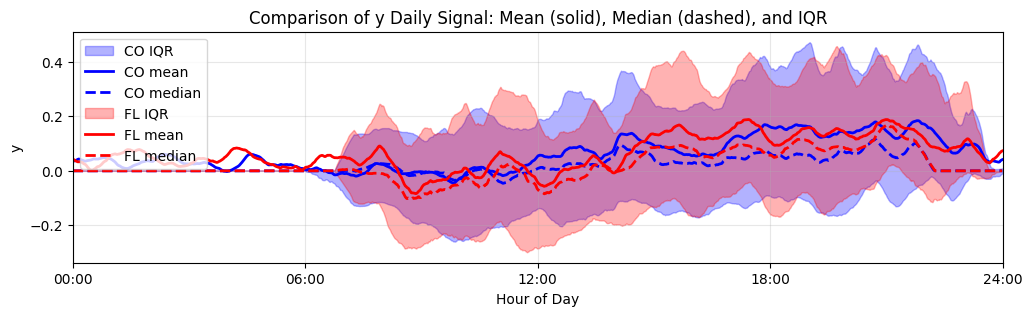

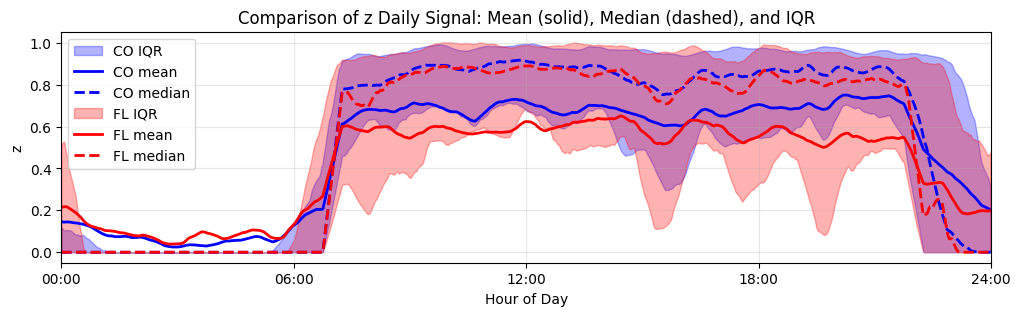

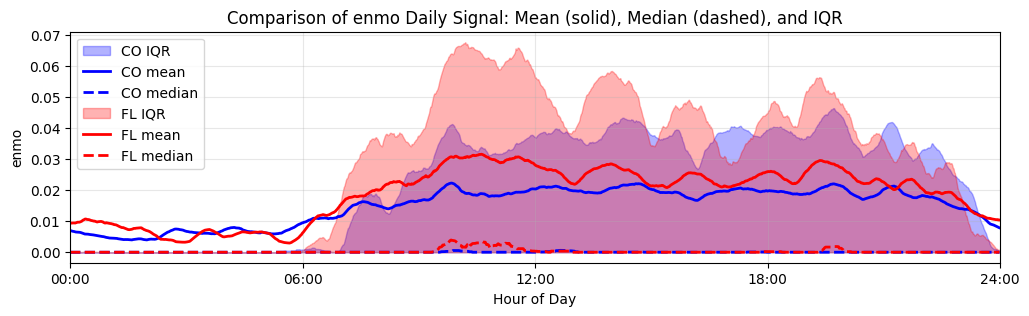

In [24]:
compare_cohorts_daily_signal(co_pattern="CO*.csv", fl_pattern="FL*.csv", folder="minute_level_modified", columns=['x','y','z','enmo'], window=30, plot_minmax=False)

### CosinorAge analysis per cohort

In [25]:
co_handlers, co_cosinor_age_inputs = load_cohort_data(modified_dir="minute_level_modified", header_dir="headers", pattern="CO*.csv", preprocess_args=None)
fl_handlers, fl_cosinor_age_inputs = load_cohort_data(modified_dir="minute_level_modified", header_dir="headers", pattern="FL*.csv", preprocess_args=None)

features_args = {}

co_features = csa.features.BulkWearableFeatures(
    handlers=co_handlers, 
    features_args=features_args,
    compute_distributions=True,
    cosinor_age_inputs=co_cosinor_age_inputs
    )

fl_features = csa.features.BulkWearableFeatures(
    handlers=fl_handlers, 
    features_args=features_args,
    compute_distributions=True,
    cosinor_age_inputs=fl_cosinor_age_inputs
    )

Error processing CO024.csv: Less than 1 day found
Error processing FL009.csv: Less than 1 day found


In [26]:
co_features.get_summary_dataframe()

,feature,count,mean,std,min,max,median,q25,q75,iqr,mode,skewness
0,cosinor_mesor,33,13.670781,13.562409,0.183037,46.142879,9.388409,2.795228,19.586284,16.791057,0.183037,1.223207
1,cosinor_amplitude,33,10.637214,9.090256,0.364836,36.245669,8.468047,3.781220,13.405471,9.624251,0.364836,1.321135
2,cosinor_acrophase,33,-3.042344,1.669654,-6.089453,-0.178364,-3.586866,-4.199024,-1.216685,2.982338,-6.089453,0.280877
3,cosinor_acrophase_time,33,697.253966,382.656396,40.877990,1395.599764,822.049166,278.843769,962.345363,683.501594,40.877990,-0.280877
4,nonparam_IS,33,0.698444,0.202922,0.344000,1.000000,0.693899,0.524805,0.816940,0.292135,1.000000,0.000607
5,nonparam_IV,33,1.048164,0.476135,0.351432,2.051661,0.952473,0.750971,1.227989,0.477018,0.351432,0.533151
6,nonparam_M10,33,22.691660,20.039651,0.439290,68.971457,15.650365,5.656280,33.946841,28.290561,0.439290,0.985694
7,nonparam_L5,33,1.162136,3.206630,0.000000,17.381094,0.000000,0.000000,0.420656,0.420656,0.000000,4.265467
8,nonparam_RA,33,0.955043,0.091427,0.571768,1.000000,1.000000,0.953624,1.000000,0.046376,1.000000,-2.786812
9,physical_activity_sedentary,33,991.621212,300.729845,349.000000,1425.000000,1075.000000,786.500000,1257.000000,470.500000,939.500000,-0.413777


In [27]:
fl_features.get_summary_dataframe()

,feature,count,mean,std,min,max,median,q25,q75,iqr,mode,skewness
0,cosinor_mesor,19,20.497148,18.591504,0.166318,55.959590,13.509339,3.168985,35.052281,31.883296,0.166318,0.580942
1,cosinor_amplitude,19,14.816321,14.137423,0.326345,49.258247,8.270809,3.819390,22.775161,18.955771,0.326345,1.114892
2,cosinor_acrophase,19,-3.954506,1.246630,-6.261845,-0.683536,-4.103725,-4.741644,-3.538004,1.203640,-6.261845,0.907247
3,cosinor_acrophase_time,19,906.306028,285.706630,156.655006,1435.109150,940.504575,810.850882,1086.704744,275.853862,156.655006,-0.907247
4,nonparam_IS,19,0.710614,0.206489,0.281681,1.000000,0.673341,0.598312,0.871128,0.272817,1.000000,-0.179042
5,nonparam_IV,19,1.034346,0.520971,0.250372,2.219653,1.027784,0.628249,1.249834,0.621585,0.250372,0.692399
6,nonparam_M10,19,32.683891,28.433907,0.399163,80.421317,21.959130,6.526312,62.816687,56.290374,0.399163,0.494155
7,nonparam_L5,19,3.277189,7.669778,0.000000,31.082527,0.000000,0.000000,0.000000,0.000000,0.000000,2.874964
8,nonparam_RA,19,0.914799,0.171888,0.428960,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,-1.878353
9,physical_activity_sedentary,19,919.368421,307.091271,425.500000,1414.000000,820.000000,721.250000,1224.750000,503.500000,425.500000,0.072134


In [28]:
co_features.get_feature_correlation_matrix()

,cosinor_mesor,cosinor_amplitude,cosinor_acrophase,cosinor_acrophase_time,nonparam_IS,nonparam_IV,nonparam_M10,nonparam_L5,nonparam_RA,physical_activity_sedentary,...,physical_activity_moderate,physical_activity_vigorous,sleep_TST,sleep_WASO,sleep_PTA,sleep_NWB,sleep_SOL,sleep_SRI,cosinorage,cosinorage_advance
cosinor_mesor,1.000000,0.896743,-0.377005,0.377005,0.395723,-0.483646,0.987744,0.628098,-0.566355,-0.917731,...,-0.170942,0.918907,-0.783546,0.750453,-0.783547,-0.205200,0.132174,0.163981,-0.487097,-0.703507
cosinor_amplitude,0.896743,1.000000,-0.317878,0.317878,0.362508,-0.622430,0.939599,0.367303,-0.291253,-0.790149,...,-0.094024,0.790913,-0.642252,0.629782,-0.642252,-0.156257,0.064269,0.114588,-0.531256,-0.712354
cosinor_acrophase,-0.377005,-0.317878,1.000000,-1.000000,-0.037286,0.253195,-0.395838,-0.164972,0.193243,0.448778,...,-0.185876,-0.447882,0.472628,-0.413987,0.472629,0.038440,-0.504130,0.324748,-0.140331,0.074358
cosinor_acrophase_time,0.377005,0.317878,-1.000000,1.000000,0.037286,-0.253195,0.395838,0.164972,-0.193243,-0.448778,...,0.185876,0.447882,-0.472628,0.413987,-0.472629,-0.038440,0.504130,-0.324748,0.140331,-0.074358
nonparam_IS,0.395723,0.362508,-0.037286,0.037286,1.000000,-0.014729,0.363426,0.103538,-0.068486,-0.463853,...,0.034309,0.463752,-0.378862,0.483924,-0.378862,-0.026992,-0.057761,0.524344,-0.235533,-0.417643
nonparam_IV,-0.483646,-0.622430,0.253195,-0.253195,-0.014729,1.000000,-0.557876,-0.088109,-0.003864,0.499622,...,0.162516,-0.500801,0.325529,-0.393310,0.325529,0.259137,-0.146351,-0.043361,0.136696,0.343752
nonparam_M10,0.987744,0.939599,-0.395838,0.395838,0.363426,-0.557876,1.000000,0.566805,-0.504145,-0.904838,...,-0.156321,0.905936,-0.761610,0.739830,-0.761610,-0.209782,0.146074,0.114014,-0.488629,-0.717836
nonparam_L5,0.628098,0.367303,-0.164972,0.164972,0.103538,-0.088109,0.566805,1.000000,-0.931601,-0.584506,...,-0.164006,0.585484,-0.454903,0.544910,-0.454905,-0.062926,-0.002959,0.182654,-0.188553,-0.347929
nonparam_RA,-0.566355,-0.291253,0.193243,-0.193243,-0.068486,-0.003864,-0.504145,-0.931601,1.000000,0.565732,...,0.061871,-0.565951,0.400486,-0.577764,0.400488,-0.092994,0.125177,-0.211520,0.074215,0.266830
physical_activity_sedentary,-0.917731,-0.790149,0.448778,-0.448778,-0.463853,0.499622,-0.904838,-0.584506,0.565732,1.000000,...,-0.016407,-0.999981,0.871799,-0.926486,0.871800,-0.000442,-0.168832,-0.123863,0.425617,0.699372


In [29]:
fl_features.get_feature_correlation_matrix()

,cosinor_mesor,cosinor_amplitude,cosinor_acrophase,cosinor_acrophase_time,nonparam_IS,nonparam_IV,nonparam_M10,nonparam_L5,nonparam_RA,physical_activity_sedentary,...,physical_activity_moderate,physical_activity_vigorous,sleep_TST,sleep_WASO,sleep_PTA,sleep_NWB,sleep_SOL,sleep_SRI,cosinorage,cosinorage_advance
cosinor_mesor,1.000000,0.801072,0.121353,-0.121353,0.309475,-0.219336,0.981882,0.710189,-0.626418,-0.855626,...,-0.389013,0.860588,-0.771335,0.800601,-0.771337,-0.228242,-0.334465,0.445465,-0.693222,-0.940764
cosinor_amplitude,0.801072,1.000000,0.119365,-0.119365,0.299123,-0.539601,0.894013,0.247951,-0.184340,-0.618080,...,-0.414803,0.624030,-0.620733,0.498343,-0.620737,-0.396183,0.013633,0.182857,-0.502463,-0.825129
cosinor_acrophase,0.121353,0.119365,1.000000,-1.000000,0.443480,0.144033,0.149917,0.113105,-0.214005,-0.413319,...,0.660132,0.400705,-0.099406,0.383105,-0.099404,0.194264,-0.421138,0.333276,-0.062766,-0.204267
cosinor_acrophase_time,-0.121353,-0.119365,-1.000000,1.000000,-0.443480,-0.144033,-0.149917,-0.113105,0.214005,0.413319,...,-0.660132,-0.400705,0.099406,-0.383105,0.099404,-0.194264,0.421138,-0.333276,0.062766,0.204267
nonparam_IS,0.309475,0.299123,0.443480,-0.443480,1.000000,0.297810,0.345750,0.154913,-0.127369,-0.498748,...,0.157376,0.494933,-0.238735,0.404085,-0.238734,0.092218,-0.332179,0.550383,-0.481544,-0.481931
nonparam_IV,-0.219336,-0.539601,0.144033,-0.144033,0.297810,1.000000,-0.306766,0.300103,-0.281041,0.114555,...,0.304050,-0.119659,0.261641,-0.047070,0.261643,0.200697,-0.263406,0.234387,0.028258,0.240461
nonparam_M10,0.981882,0.894013,0.149917,-0.149917,0.345750,-0.306766,1.000000,0.617152,-0.538084,-0.832733,...,-0.411722,0.838131,-0.760754,0.760482,-0.760757,-0.286901,-0.262987,0.392690,-0.651929,-0.950232
nonparam_L5,0.710189,0.247951,0.113105,-0.113105,0.154913,0.300103,0.617152,1.000000,-0.908665,-0.645556,...,-0.169469,0.647071,-0.464617,0.705955,-0.464616,-0.027668,-0.569992,0.471760,-0.460137,-0.606882
nonparam_RA,-0.626418,-0.184340,-0.214005,0.214005,-0.127369,-0.281041,-0.538084,-0.908665,1.000000,0.679818,...,0.062417,-0.679229,0.470995,-0.761010,0.470994,-0.004713,0.653524,-0.450601,0.287547,0.452900
physical_activity_sedentary,-0.855626,-0.618080,-0.413319,0.413319,-0.498748,0.114555,-0.832733,-0.645556,0.679818,1.000000,...,0.120636,-0.999850,0.791952,-0.938628,0.791951,-0.070941,0.564992,-0.582836,0.597646,0.813182


### Feature distribution per cohort

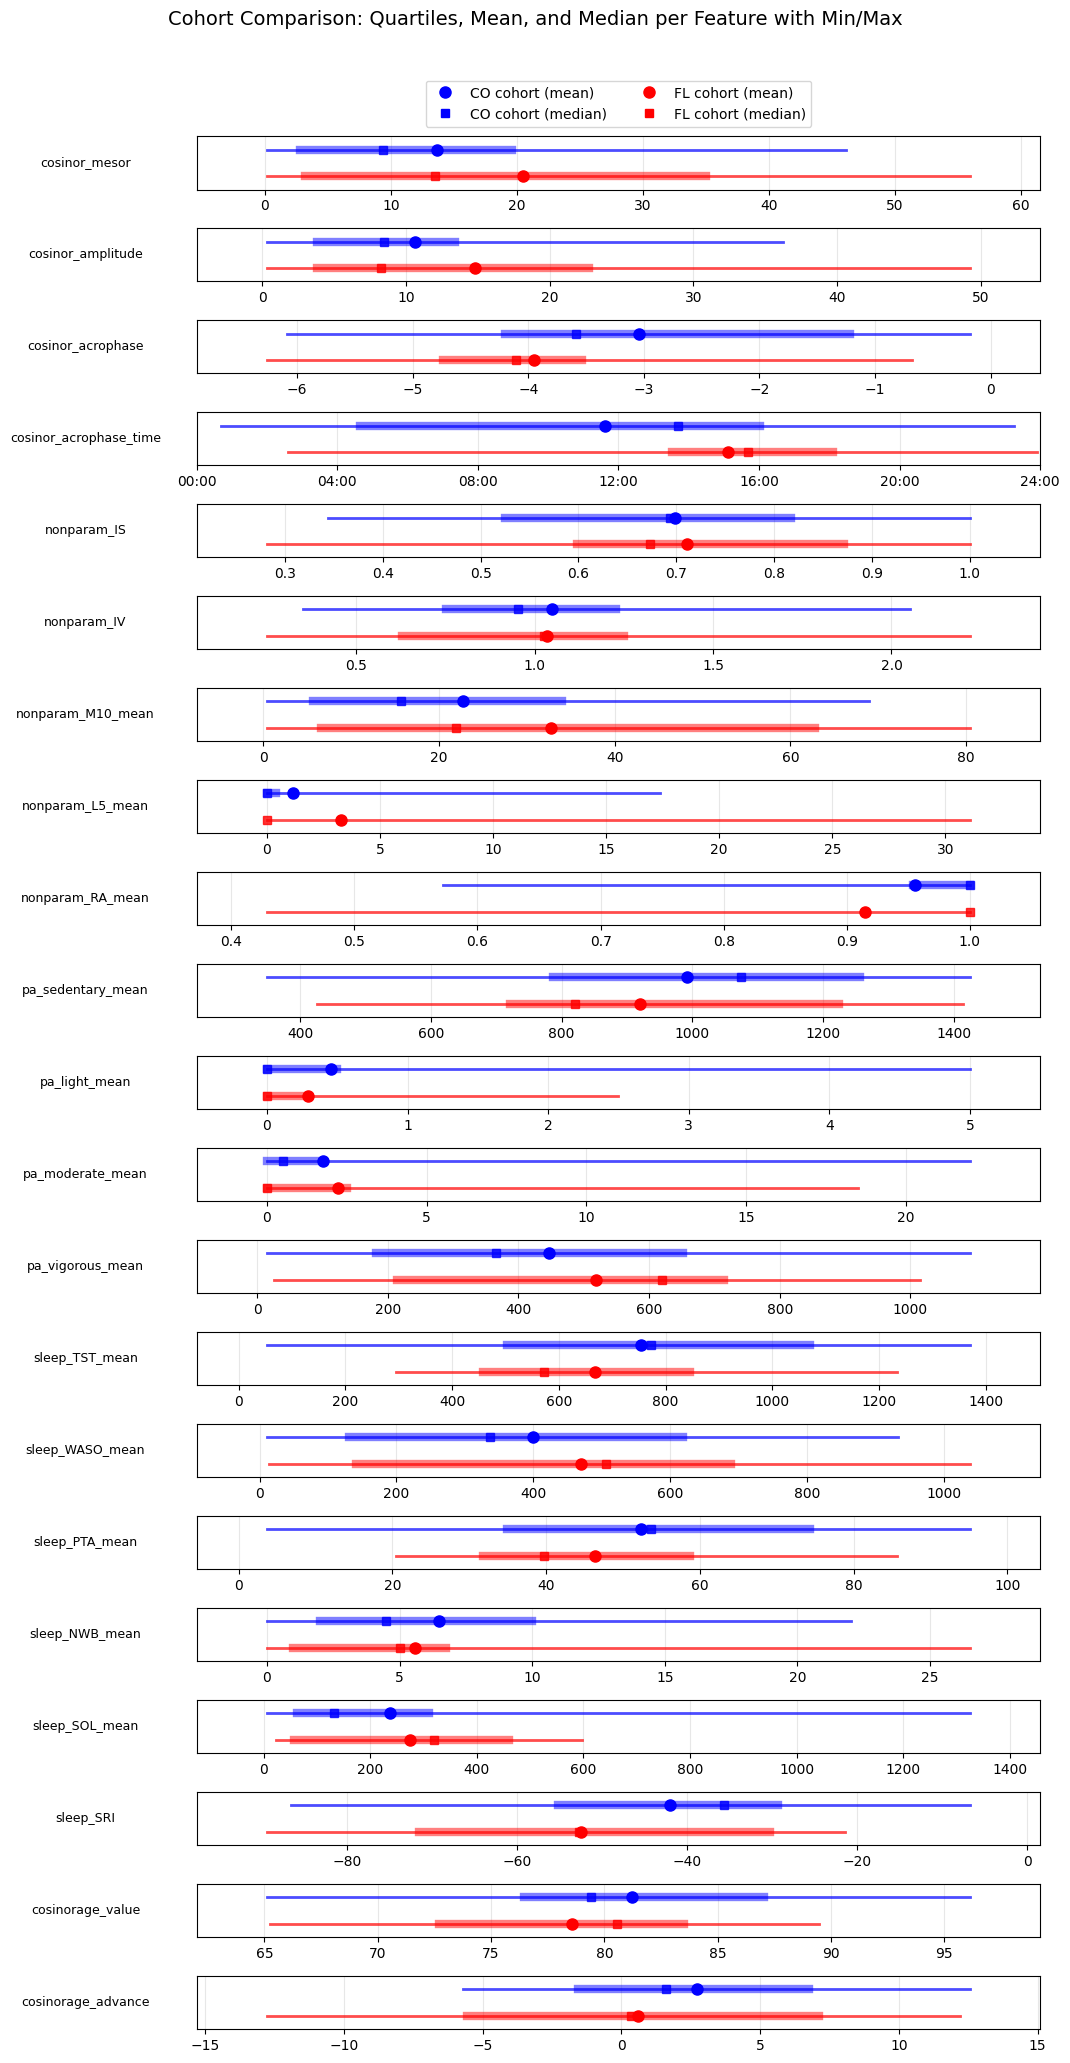

In [30]:
plot_cohort_feature_comparison(co_features, fl_features, title=None, plot_minmax=True)